In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import linregress

In [2]:
deepcsa_run_dir = '/data/bbg/nobackup2/scratch/mhuertas/tests_dupcaller/20260624_bladder_rerun'

## dN/dS comparisons

### omega

In [3]:
# omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
# omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omega_globalloc.tsv")
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omega/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,missense,1,0.332614,0.179826,0.019452,1.471530,0.340571,False,NaN
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsense,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
2,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,truncating,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
3,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsynonymous_splice,5,1.432809,0.450743,0.511596,3.105783,0.581779,False,NaN
4,KMT2D--PHD/RING_ZnF,P19_0051_BDO_01_dupcaller,missense,2,0.861719,0.829799,0.143081,2.684229,0.884412,False,NaN


In [4]:
reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller, on = ["gene", "impact"], suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--"))]

reduced_omegas

,gene,sample_deepumicaller,impact,mutations_deepumicaller,dnds_deepumicaller,pvalue_deepumicaller,lower_deepumicaller,upper_deepumicaller,pvalue_adj_deepumicaller,flagged_deepumicaller,flag_reason_deepumicaller,sample_dupcaller,mutations_dupcaller,dnds_dupcaller,pvalue_dupcaller,lower_dupcaller,upper_dupcaller,pvalue_adj_dupcaller,flagged_dupcaller,flag_reason_dupcaller
9,RB1,CallerDeepumicaller,missense,24,0.993945,9.777449e-01,0.640340,1.467578,9.777449e-01,False,NaN,CallerDupcaller,39,0.773437,1.110144e-01,0.549029,1.057861,1.259268e-01,False,NaN
10,RB1,CallerDeepumicaller,truncating,7,1.639063,2.323667e-01,0.698056,3.218652,2.522838e-01,False,NaN,CallerDupcaller,11,1.225098,5.230014e-01,0.629415,2.131470,5.444946e-01,False,NaN
32,TERTpromoter,CallerDeepumicaller,missense,4,58.512500,7.748604e-07,17.808200,141.082690,1.143483e-06,False,NaN,CallerDupcaller,12,27.775000,1.170000e-38,14.348358,49.081152,1.852500e-38,False,NaN
35,KMT2C,CallerDeepumicaller,missense,61,1.457813,8.873820e-03,1.103636,1.891162,1.143068e-02,False,NaN,CallerDupcaller,103,1.276563,2.903044e-02,1.026095,1.572583,3.587502e-02,False,NaN
36,KMT2C,CallerDeepumicaller,truncating,19,3.411720,1.895428e-05,2.035584,5.390479,2.643165e-05,False,NaN,CallerDupcaller,33,2.972656,5.960465e-07,1.998365,4.284302,8.970204e-07,False,NaN
44,FOXQ1,CallerDeepumicaller,missense,49,2.478125,1.192093e-07,1.809875,3.312476,1.848960e-07,True,high_mutdensity - zscore > 2,CallerDupcaller,91,2.143750,1.170000e-38,1.682722,2.699170,1.852500e-38,True,high_mutdensity - zscore > 2
45,FOXQ1,CallerDeepumicaller,truncating,5,2.153122,1.393581e-01,0.749838,4.871628,1.557532e-01,True,high_mutdensity - zscore > 2,CallerDupcaller,9,2.299219,3.410155e-02,1.071893,4.331079,4.146748e-02,True,high_mutdensity - zscore > 2
65,TP53,CallerDeepumicaller,missense,48,4.793750,1.170000e-38,3.513723,6.378223,1.852500e-38,False,NaN,CallerDupcaller,84,3.674988,1.170000e-38,2.895641,4.604553,1.852500e-38,False,NaN
66,TP53,CallerDeepumicaller,truncating,5,3.265625,2.789044e-02,1.161709,7.121826,3.474875e-02,False,NaN,CallerDupcaller,8,2.521875,2.486885e-02,1.140834,4.767358,3.124020e-02,False,NaN
67,CDKN1A,CallerDeepumicaller,missense,9,0.907910,7.706637e-01,0.433526,1.653149,7.809393e-01,False,NaN,CallerDupcaller,37,1.425000,5.067074e-02,0.999395,1.966992,6.064530e-02,False,NaN


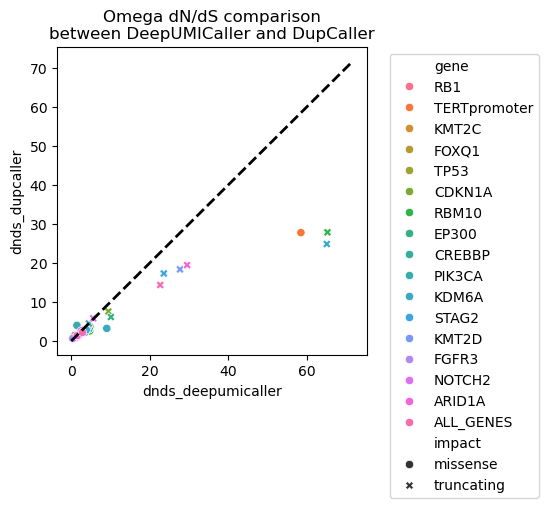

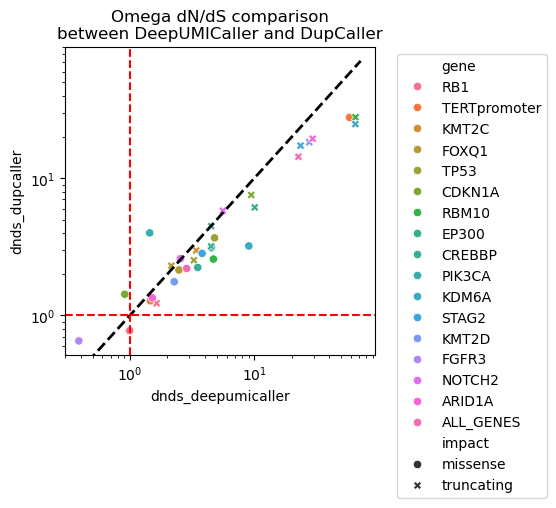

In [5]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/omega_dnds.deepumicaller_vs_dupcaller.pdf", bbox_inches='tight', dpi=300)
plt.show()


plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/omega_dnds.deepumicaller_vs_dupcaller.log.pdf", bbox_inches='tight', dpi=300)

plt.show()


### Omega globalloc

In [6]:
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omegas_global_loc.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0053_BDO_01,missense,1,1.517236,0.696591,0.086539,6.719263,0.729468
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0053_BDO_01,nonsynonymous_splice,1,1.344946,0.777795,0.077138,5.951880,0.803457
2,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,nonsense,1,43.600024,0.018125,2.473645,195.940112,0.042168
3,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,truncating,1,43.600024,0.018125,2.473645,195.940112,0.042168
4,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,nonsynonymous_splice,1,2.392969,0.446530,0.136828,10.590601,0.496664


In [7]:
reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller, on = ["gene", "impact"], suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--"))]

reduced_omegas

,gene,sample_deepumicaller,impact,mutations_deepumicaller,dnds_deepumicaller,pvalue_deepumicaller,lower_deepumicaller,upper_deepumicaller,pvalue_adj_deepumicaller,sample_dupcaller,mutations_dupcaller,dnds_dupcaller,pvalue_dupcaller,lower_dupcaller,upper_dupcaller,pvalue_adj_dupcaller
22,RB1,CallerDeepumicaller,missense,24,1.110156,6.257715e-01,0.715325,1.638721,6.341151e-01,CallerDupcaller,39,0.742969,6.354046e-02,0.526800,1.015796,7.316780e-02
23,RB1,CallerDeepumicaller,truncating,7,1.830469,1.506086e-01,0.779788,3.593774,1.658877e-01,CallerDupcaller,11,1.176564,6.069159e-01,0.604674,2.046925,6.191357e-01
64,TERTpromoter,CallerDeepumicaller,missense,4,39.103125,3.874302e-06,11.899712,94.274023,5.608513e-06,CallerDupcaller,12,28.493750,1.170000e-38,14.714319,50.333350,1.852500e-38
68,KMT2C,CallerDeepumicaller,missense,61,1.588281,1.493990e-03,1.202188,2.060083,1.924462e-03,CallerDupcaller,103,1.257031,4.057384e-02,1.010426,1.548169,4.933778e-02
69,KMT2C,CallerDeepumicaller,truncating,19,3.715820,5.900860e-06,2.216664,5.871582,8.304914e-06,CallerDupcaller,33,2.926563,8.344650e-07,1.967429,4.218677,1.268387e-06
93,FOXQ1,CallerDeepumicaller,missense,49,3.193359,1.170000e-38,2.334567,4.271851,1.852500e-38,CallerDupcaller,91,1.917188,4.172325e-07,1.504646,2.413403,6.471361e-07
94,FOXQ1,CallerDeepumicaller,truncating,5,2.778125,5.682409e-02,0.966949,6.282764,6.747860e-02,CallerDupcaller,9,2.056153,6.284112e-02,0.959143,3.873169,7.291489e-02
144,TP53,CallerDeepumicaller,missense,48,5.535938,1.170000e-38,4.060016,7.370044,1.852500e-38,CallerDupcaller,84,3.455469,1.170000e-38,2.721961,4.328882,1.852500e-38
145,TP53,CallerDeepumicaller,truncating,5,3.775000,1.548839e-02,1.342825,8.228735,1.961862e-02,CallerDupcaller,8,2.369141,3.472245e-02,1.072650,4.482178,4.256300e-02
147,CDKN1A,CallerDeepumicaller,missense,9,1.039819,9.082069e-01,0.496248,1.894312,9.142216e-01,CallerDupcaller,37,1.323438,1.170771e-01,0.929021,1.828809,1.308509e-01


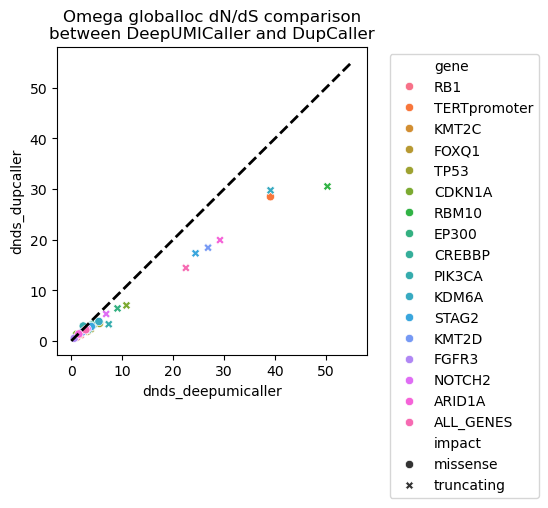

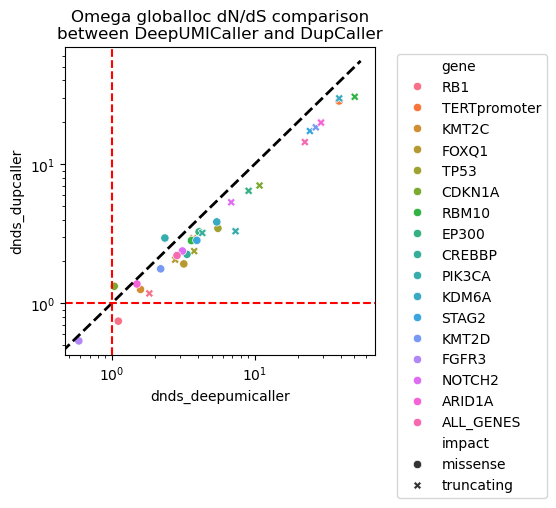

In [8]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega globalloc dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/omegagloballoc_dnds.deepumicaller_vs_dupcaller.pdf", bbox_inches='tight', dpi=300)
plt.show()


plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega globalloc dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/omegagloballoc_dnds.deepumicaller_vs_dupcaller.log.pdf", bbox_inches='tight', dpi=300)
plt.show()


### dNdScv

In [9]:
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/dndscv/cv/all_dNdScv.cv.tsv")
omegas.head()

,sample,theta,theta_ind,gene_name,n_syn,n_mis,n_non,n_spl,n_ind,wmis_cv,...,pmis_cv,ptrunc_cv,pallsubs_cv,pind_cv,qmis_cv,qtrunc_cv,qallsubs_cv,qind_cv,pglobal_cv,qglobal_cv
0,P19_0050_BTR_01_dupcaller,1.61345,0.3167,KMT2D,60,221,234,58,84,1.553459,...,0.001573,0.000000e+00,0.000000e+00,0.298950,0.005090,0.000000e+00,0.000000e+00,0.747375,0.000000e+00,0.000000e+00
1,P19_0050_BTR_01_dupcaller,1.61345,0.3167,RBM10,20,79,99,49,63,2.069878,...,0.001697,0.000000e+00,0.000000e+00,0.017427,0.005090,0.000000e+00,0.000000e+00,0.107211,0.000000e+00,0.000000e+00
2,P19_0050_BTR_01_dupcaller,1.61345,0.3167,KDM6A,9,32,38,27,55,1.529963,...,0.230735,0.000000e+00,0.000000e+00,0.034879,0.314639,0.000000e+00,0.000000e+00,0.130795,0.000000e+00,0.000000e+00
3,P19_0050_BTR_01_dupcaller,1.61345,0.3167,ARID1A,16,55,106,18,51,1.329158,...,0.297612,0.000000e+00,0.000000e+00,0.231557,0.372014,0.000000e+00,0.000000e+00,0.694672,0.000000e+00,0.000000e+00
4,P19_0050_BTR_01_dupcaller,1.61345,0.3167,EP300,11,85,25,16,7,2.704568,...,0.000327,4.631628e-12,3.033962e-11,0.559845,0.002455,1.389489e-11,9.101886e-11,0.825429,4.382028e-10,1.314608e-09


In [10]:
omegas = omegas.melt(id_vars=["sample", "gene_name"], value_vars=['wmis_cv', 'wnon_cv', 'wind_cv'], var_name='impact', value_name='dnds')
omegas

,sample,gene_name,impact,dnds
0,P19_0050_BTR_01_dupcaller,KMT2D,wmis_cv,1.553459
1,P19_0050_BTR_01_dupcaller,RBM10,wmis_cv,2.069878
2,P19_0050_BTR_01_dupcaller,KDM6A,wmis_cv,1.529963
3,P19_0050_BTR_01_dupcaller,ARID1A,wmis_cv,1.329158
4,P19_0050_BTR_01_dupcaller,EP300,wmis_cv,2.704568
...,...,...,...,...
850,P19_0052_BTR_01_dupcaller,CDKN1A,wind_cv,0.000000
851,P19_0052_BTR_01_dupcaller,FGFR3,wind_cv,0.000000
852,P19_0052_BTR_01_dupcaller,RBM10,wind_cv,0.000000
853,P19_0052_BTR_01_dupcaller,KMT2C,wind_cv,0.316594


In [11]:
reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller,
                                                    on = ["gene_name", "impact"],
                                                    suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene_name"].str.contains("--"))]

reduced_omegas

,sample_deepumicaller,gene_name,impact,dnds_deepumicaller,sample_dupcaller,dnds_dupcaller
0,CallerDeepumicaller,EP300,wmis_cv,3.825024,CallerDupcaller,2.748532
1,CallerDeepumicaller,KMT2D,wmis_cv,2.037206,CallerDupcaller,1.624539
2,CallerDeepumicaller,RBM10,wmis_cv,3.493966,CallerDupcaller,2.061442
3,CallerDeepumicaller,KDM6A,wmis_cv,5.188568,CallerDupcaller,2.596651
4,CallerDeepumicaller,STAG2,wmis_cv,2.176259,CallerDupcaller,2.044615
5,CallerDeepumicaller,ARID1A,wmis_cv,1.478775,CallerDupcaller,1.200079
6,CallerDeepumicaller,NOTCH2,wmis_cv,2.132108,CallerDupcaller,2.137558
7,CallerDeepumicaller,FOXQ1,wmis_cv,4.806451,CallerDupcaller,2.355557
8,CallerDeepumicaller,CREBBP,wmis_cv,2.732145,CallerDupcaller,1.820466
9,CallerDeepumicaller,CDKN1A,wmis_cv,2.138864,CallerDupcaller,2.004564


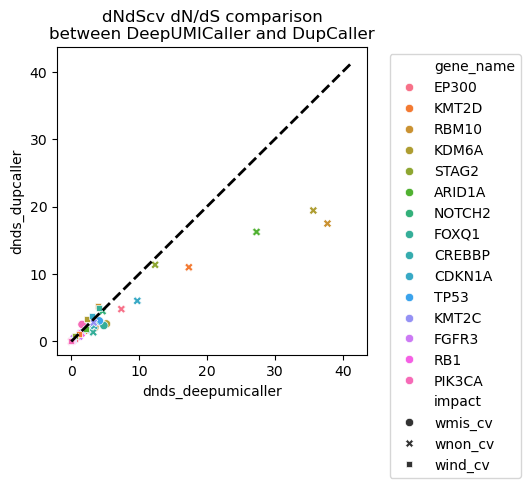

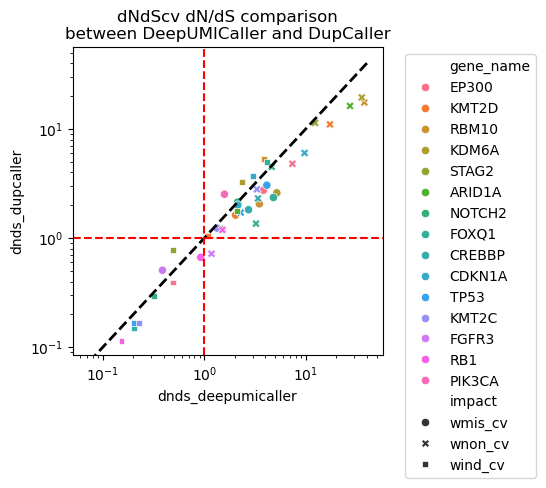

In [12]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/dndscv_dnds.deepumicaller_vs_dupcaller.pdf", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/dndscv_dnds.deepumicaller_vs_dupcaller.log.pdf", bbox_inches='tight', dpi=300)
plt.show()

### Domain level -- omega

In [13]:
# omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
# omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omegas_global_loc.tsv")
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omega/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,missense,1,0.332614,0.179826,0.019452,1.471530,0.340571,False,NaN
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsense,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
2,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,truncating,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
3,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsynonymous_splice,5,1.432809,0.450743,0.511596,3.105783,0.581779,False,NaN
4,KMT2D--PHD/RING_ZnF,P19_0051_BDO_01_dupcaller,missense,2,0.861719,0.829799,0.143081,2.684229,0.884412,False,NaN


In [14]:
omegas = omegas[~(omegas["gene"].str.contains("--exon"))
                & (omegas["gene"].str.contains("--"))
                ]

In [15]:
reduced_omegas = omegas[(omegas["gene"].str.contains("RBM10"))
                          & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                          & (omegas["impact"].isin(['missense']))
                          ]
reduced_omegas.sort_values(by=["gene", "sample", "impact"])

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
2744,RBM10--G-patch,CallerDupcaller,missense,6,2.746875,3.522998e-02,1.083769,5.630786,6.687866e-02,False,NaN
4310,RBM10--RBM10_OCRE,CallerDeepumicaller,missense,10,3.590601,9.116530e-04,1.788062,6.365869,2.277006e-03,False,NaN
2715,RBM10--RBM10_OCRE,CallerDupcaller,missense,20,3.795313,1.370907e-06,2.344399,5.783838,4.644887e-06,False,NaN
3062,RBM10--RBM10_RRM_2,CallerDupcaller,missense,69,22.975000,1.170000e-38,17.680183,29.371484,4.697550e-38,False,NaN
2120,RBM10--RRM_domain,CallerDupcaller,missense,4,0.262085,7.343888e-04,0.081884,0.613647,1.863236e-03,False,NaN
4288,RBM10--RanBP2_ZnF,CallerDeepumicaller,missense,2,0.757373,6.821539e-01,0.126047,2.357715,7.427385e-01,False,NaN
2686,RBM10--RanBP2_ZnF,CallerDupcaller,missense,3,1.259277,7.023026e-01,0.311949,3.290527,7.610648e-01,False,NaN
4109,RBM10--ZnF_C2H2_type,CallerDeepumicaller,missense,33,5.431226,1.170000e-38,3.728490,7.632764,4.697550e-38,False,NaN
2388,RBM10--ZnF_C2H2_type,CallerDupcaller,missense,51,6.721863,1.170000e-38,4.960327,8.913635,4.697550e-38,False,NaN


In [16]:
reduced_omegas = omegas[(omegas["gene"].str.contains("TP53"))
                          & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                          & (omegas["impact"].isin(['missense']))
                          ]
reduced_omegas.sort_values(by=["gene", "sample", "impact"])

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
3125,TP53--p53_DBD,CallerDupcaller,missense,72,28.374219,1.170000e-38,21.946219,36.128735,4.697550e-38,False,NaN
3017,TP53--p53_Tetramer,CallerDupcaller,missense,3,0.557129,2.647064e-01,0.138233,1.453735,3.621112e-01,False,NaN


### Domain level -- omega globalloc

In [17]:
# omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omegas_global_loc.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0053_BDO_01,missense,1,1.517236,0.696591,0.086539,6.719263,0.729468
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0053_BDO_01,nonsynonymous_splice,1,1.344946,0.777795,0.077138,5.951880,0.803457
2,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,nonsense,1,43.600024,0.018125,2.473645,195.940112,0.042168
3,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,truncating,1,43.600024,0.018125,2.473645,195.940112,0.042168
4,KMT2D--PHD/RING_ZnF,P19_0053_BDO_01,nonsynonymous_splice,1,2.392969,0.446530,0.136828,10.590601,0.496664


In [18]:
omegas = omegas[~(omegas["gene"].str.contains("--exon"))
                & (omegas["gene"].str.contains("--"))
                ]

In [19]:
reduced_omegas = omegas[(omegas["gene"].str.contains("RBM10"))
                          & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                          & (omegas["impact"].isin(['missense']))
                          ]
reduced_omegas.sort_values(by=["gene", "sample", "impact"])

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj
8196,RBM10--G-patch,CallerDeepumicaller,missense,2,0.992200,9.910820e-01,0.165387,3.086926,9.933381e-01
14141,RBM10--G-patch,CallerDupcaller,missense,6,1.079785,8.541204e-01,0.426318,2.214429,8.795605e-01
8130,RBM10--RBM10_OCRE,CallerDeepumicaller,missense,10,3.362500,1.512408e-03,1.673154,5.958325,3.897360e-03
14070,RBM10--RBM10_OCRE,CallerDupcaller,missense,20,3.031055,3.540516e-05,1.871607,4.616138,1.226053e-04
8624,RBM10--RBM10_RRM_2,CallerDeepumicaller,missense,36,19.260938,1.170000e-38,13.491179,26.590649,6.238651e-38
14642,RBM10--RBM10_RRM_2,CallerDupcaller,missense,69,11.762305,1.170000e-38,9.054483,15.041113,6.238651e-38
7307,RBM10--RRM_domain,CallerDeepumicaller,missense,2,0.810937,7.588401e-01,0.134364,2.522363,7.990247e-01
13140,RBM10--RRM_domain,CallerDupcaller,missense,4,0.526367,1.555457e-01,0.162792,1.234375,2.175098e-01
8099,RBM10--RanBP2_ZnF,CallerDeepumicaller,missense,2,2.562494,2.508414e-01,0.425030,7.970819,3.218540e-01
14039,RBM10--RanBP2_ZnF,CallerDupcaller,missense,3,1.542188,4.853217e-01,0.382573,4.033643,5.533709e-01


In [20]:
reduced_omegas = omegas[(omegas["gene"].str.contains("TP53"))
                          & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                          & (omegas["impact"].isin(['missense']))
                          ]
reduced_omegas.sort_values(by=["gene", "sample", "impact"])

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj
7400,TP53--p53,CallerDeepumicaller,missense,5,23.737500,2.801418e-06,8.421937,52.016919,1.158922e-05
13244,TP53--p53,CallerDupcaller,missense,11,15.825000,1.170000e-38,8.088353,27.737842,6.238651e-38
8702,TP53--p53_DBD,CallerDeepumicaller,missense,43,11.393750,1.170000e-38,8.210135,15.390332,6.238651e-38
14729,TP53--p53_DBD,CallerDupcaller,missense,72,6.593701,1.170000e-38,5.100474,8.395459,6.238651e-38
14570,TP53--p53_Tetramer,CallerDupcaller,missense,3,1.150000,8.127840e-01,0.285537,3.002417,8.437185e-01


## Indels comparisons

### Indel mutation density

In [21]:
mutation_densities = pd.read_table(f"{deepcsa_run_dir}/mutdensity/all_mutdensities.tsv")
mutation_densities.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED
0,CallerDupcaller,ALL_GENES,all,all_types,12438489295,10867.0,18664.0,0.873659,0.873659,1.500504,1.500504
1,CallerDupcaller,ALL_GENES,all,SNV,12438489295,9246.0,15339.0,0.743338,0.743338,1.233188,1.233188
2,CallerDupcaller,ALL_GENES,all,DELETION-INSERTION,12438489295,1620.0,3324.0,0.130241,0.130241,0.267235,0.267235
3,CallerDupcaller,ALL_GENES,all,DELETION-INSERTION-SNV,12438489295,10866.0,18663.0,0.873579,0.873579,1.500423,1.500423
4,CallerDupcaller,ANKS1A,all,all_types,336103,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [22]:
selected_genes = ['TP53', 'RBM10', 'KDM6A', 'ARID1A', 'KMT2D', 'KMT2C', 'CDKN1A',
                  'CREBBP', 'EP300', 'STAG2', 'NOTCH2', 'PIK3CA', 'FGFR3',
                #   'TERTpromoter',
                  'FOXQ1']

mutation_type = 'indels'

mutation_densities_of_interest = mutation_densities[
    (mutation_densities["MUTTYPES"] == 'DELETION-INSERTION')
    # (mutation_densities["MUTTYPES"] == 'SNV')
    & (mutation_densities["SAMPLE_ID"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
    & (mutation_densities["GENE"].isin(selected_genes))
    & (mutation_densities["REGIONS"].isin(["protein_affecting", "all"]))
    ]
mutation_densities_of_interest.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED
1114,CallerDupcaller,ARID1A,all,DELETION-INSERTION,1261595859,327.0,635.0,0.259196,0.259196,0.503331,0.503331
1138,CallerDupcaller,CDKN1A,all,DELETION-INSERTION,87478863,38.0,92.0,0.434391,0.434391,1.051683,1.051683
1142,CallerDupcaller,CREBBP,all,DELETION-INSERTION,1368016461,36.0,48.0,0.026315,0.026315,0.035087,0.035087
1190,CallerDupcaller,EP300,all,DELETION-INSERTION,1459629243,79.0,335.0,0.054123,0.054123,0.229510,0.229510
1236,CallerDupcaller,FGFR3,all,DELETION-INSERTION,129119548,1.0,1.0,0.007745,0.007745,0.007745,0.007745


In [23]:
reduced_mutdensities_deepumicaller = mutation_densities_of_interest[(mutation_densities_of_interest["SAMPLE_ID"] == 'CallerDeepumicaller')]
reduced_mutdensities_dupcaller = mutation_densities_of_interest[(mutation_densities_of_interest["SAMPLE_ID"] == 'CallerDupcaller')]

reduced_mutdensities = reduced_mutdensities_deepumicaller.merge(reduced_mutdensities_dupcaller,
                                                    on = ["GENE", "REGIONS"],
                                                    suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
# reduced_omegas = reduced_omegas[~(reduced_omegas["GENE"].str.contains("--"))]

reduced_mutdensities[['SAMPLE_ID_deepumicaller', 'GENE', 'REGIONS', 'MUTTYPES_deepumicaller',
                      'MUTDENSITY_MB_deepumicaller', 'MUTDENSITY_MB_dupcaller']]

,SAMPLE_ID_deepumicaller,GENE,REGIONS,MUTTYPES_deepumicaller,MUTDENSITY_MB_deepumicaller,MUTDENSITY_MB_dupcaller
0,CallerDeepumicaller,ARID1A,protein_affecting,DELETION-INSERTION,1.078402,0.395301
1,CallerDeepumicaller,CDKN1A,protein_affecting,DELETION-INSERTION,1.687501,0.771829
2,CallerDeepumicaller,CREBBP,protein_affecting,DELETION-INSERTION,0.066801,0.026361
3,CallerDeepumicaller,EP300,protein_affecting,DELETION-INSERTION,0.214446,0.071713
4,CallerDeepumicaller,FGFR3,protein_affecting,DELETION-INSERTION,0.037998,0.000000
5,CallerDeepumicaller,FOXQ1,protein_affecting,DELETION-INSERTION,2.697236,1.303956
6,CallerDeepumicaller,KDM6A,protein_affecting,DELETION-INSERTION,1.144751,0.648115
7,CallerDeepumicaller,KMT2C,protein_affecting,DELETION-INSERTION,0.088859,0.025530
8,CallerDeepumicaller,KMT2D,protein_affecting,DELETION-INSERTION,0.547466,0.230069
9,CallerDeepumicaller,NOTCH2,protein_affecting,DELETION-INSERTION,0.152856,0.054168


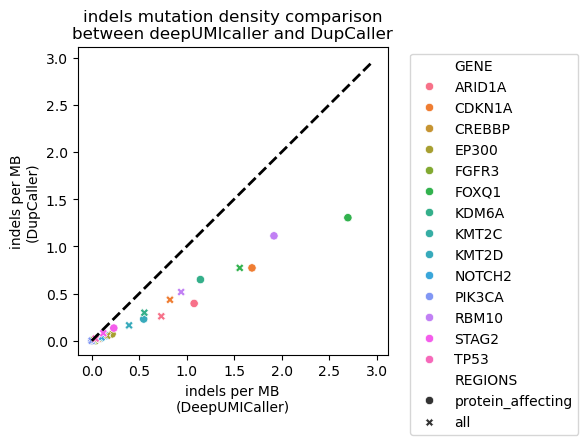

In [24]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=reduced_mutdensities, x="MUTDENSITY_MB_deepumicaller", y="MUTDENSITY_MB_dupcaller",
            hue = 'GENE',
            style = "REGIONS",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_mutdensities["MUTDENSITY_MB_deepumicaller"].max(), reduced_mutdensities["MUTDENSITY_MB_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel(f"{mutation_type} per MB\n(DeepUMICaller)")
plt.ylabel(f"{mutation_type} per MB\n(DupCaller)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"{mutation_type} mutation density comparison\nbetween deepUMIcaller and DupCaller")
plt.savefig("../plots/indel_mutation_density.deepumicaller_vs_dupcaller.pdf", bbox_inches='tight', dpi=300)
plt.show()


### dNdScv only indels

In [25]:
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/dndscv/cv/all_dNdScv.cv.tsv")
omegas.head()
omegas = omegas.melt(id_vars=["sample", "gene_name"], value_vars=['wmis_cv', 'wnon_cv', 'wind_cv'], var_name='impact', value_name='dnds')

reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller,
                                                    on = ["gene_name", "impact"],
                                                    suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene_name"].str.contains("--"))]

reduced_omegas.head()

,sample_deepumicaller,gene_name,impact,dnds_deepumicaller,sample_dupcaller,dnds_dupcaller
0,CallerDeepumicaller,EP300,wmis_cv,3.825024,CallerDupcaller,2.748532
1,CallerDeepumicaller,KMT2D,wmis_cv,2.037206,CallerDupcaller,1.624539
2,CallerDeepumicaller,RBM10,wmis_cv,3.493966,CallerDupcaller,2.061442
3,CallerDeepumicaller,KDM6A,wmis_cv,5.188568,CallerDupcaller,2.596651
4,CallerDeepumicaller,STAG2,wmis_cv,2.176259,CallerDupcaller,2.044615


In [26]:
reduced_omegas = reduced_omegas[(reduced_omegas["impact"] == 'wind_cv')]

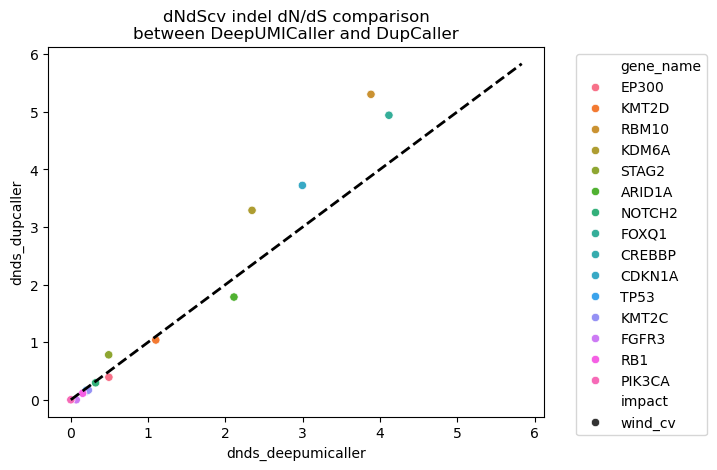

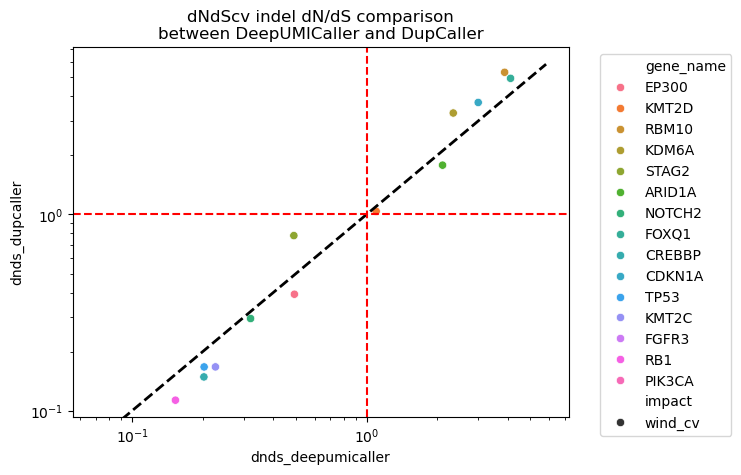

In [27]:
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv indel dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()


sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv indel dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.savefig("../plots/indel_dnds.deepumicaller_vs_dupcaller.log.pdf", bbox_inches='tight', dpi=300)
plt.show()

### indel mutation density vs dN/dS

#### deepUMIcaller

In [28]:
deepumicaller_dnds_mutdensity = reduced_omegas_deepumicaller.merge(reduced_mutdensities_deepumicaller[reduced_mutdensities_deepumicaller["REGIONS"] == 'protein_affecting'],
                                   left_on=["gene_name"],
                                   right_on=["GENE"])
deepumicaller_dnds_mutdensity.head()

,sample,gene_name,impact,dnds,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED
0,CallerDeepumicaller,EP300,wmis_cv,3.825024,CallerDeepumicaller,EP300,protein_affecting,DELETION-INSERTION,429013020,92.0,211.0,0.214446,0.231446,0.491827,0.530817
1,CallerDeepumicaller,KMT2D,wmis_cv,2.037206,CallerDeepumicaller,KMT2D,protein_affecting,DELETION-INSERTION,878593171,481.0,626.0,0.547466,0.590466,0.712503,0.768465
2,CallerDeepumicaller,RBM10,wmis_cv,3.493966,CallerDeepumicaller,RBM10,protein_affecting,DELETION-INSERTION,119335964,229.0,384.0,1.918952,2.078010,3.217806,3.484524
3,CallerDeepumicaller,KDM6A,wmis_cv,5.188568,CallerDeepumicaller,KDM6A,protein_affecting,DELETION-INSERTION,139768359,160.0,201.0,1.144751,1.245711,1.438094,1.564925
4,CallerDeepumicaller,STAG2,wmis_cv,2.176259,CallerDeepumicaller,STAG2,protein_affecting,DELETION-INSERTION,141701589,33.0,33.0,0.232884,0.255894,0.232884,0.255894


/tmp/ipykernel_3815077/1166543519.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


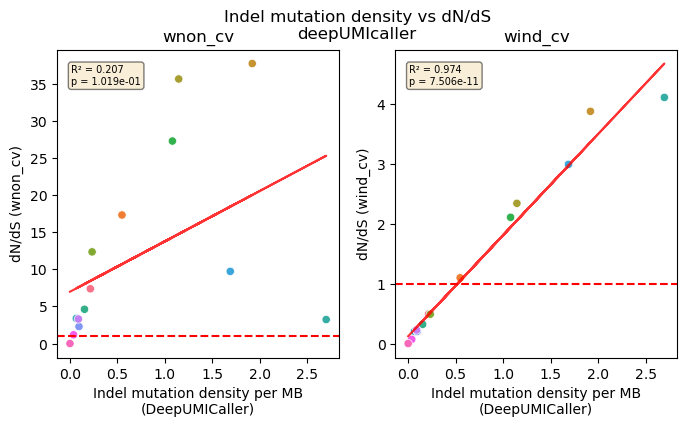

In [34]:
# # Scatterplot for correlation with distinction for significance
# ax3 = axes[1,0]
# merged_df['significance'] = merged_df['pvalue'] < 0.05
# sns.scatterplot(data=merged_df, x='MUTDENSITY_MB', y='dnds',
#                     hue='significance', style='significance',
#                     ax=ax3, palette={True: 'red', False: 'blue'},
#                     markers={True: 'o', False: 'X'}, s=20)
# ax3.set_xlabel('Mutation Density (DELETION-INSERTION)')
# ax3.set_ylabel('dN/dS (Truncating)')
# ax3.set_title('Correlation: Mutation Density vs dN/dS')


# # Annotate points with gene names
# for i, row in merged_df.iterrows():
#     ax3.annotate(row['GENE'], (row['MUTDENSITY_MB'], row['dnds']), 
#                 xytext=(2, 2), textcoords='offset points', fontsize=5,
#                 alpha=0.7)


fig, axes = plt.subplots(figsize=(8, 4), nrows=1, ncols=2)
for impact in ['wnon_cv', 'wind_cv']:
    axis = axes[0] if impact == 'wnon_cv' else axes[1]
    # print(deepumicaller_dnds_mutdensity[deepumicaller_dnds_mutdensity["impact"] == impact])
    selected_df = deepumicaller_dnds_mutdensity[deepumicaller_dnds_mutdensity["impact"] == impact]
    sns.scatterplot(data=selected_df,
                x="MUTDENSITY_MB",
                y="dnds",
                hue = 'gene_name',
                ax=axis,
                legend=False,
            # kind="box",
            # height=4, aspect=1.5
            )
    # Add regression line
    slope, intercept, r_value, p_value, std_err = linregress(selected_df['MUTDENSITY_MB'], selected_df['dnds'])
    line = slope * selected_df['MUTDENSITY_MB'] + intercept
    axis.plot(selected_df['MUTDENSITY_MB'], line, 'r', alpha=0.8)
    axis.text(0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.3e}', 
                transform=axis.transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize = 7
                )

    axis.set_title(f"{impact}")
    axis.set_xlabel(f"Indel mutation density per MB\n(DeepUMICaller)")
    axis.set_ylabel(f"dN/dS ({impact})")
    axis.axhline(y=1, color='r', linestyle='--')

    # max_dnds = max(deepumicaller_dnds_mutdensity["dnds_deepumicaller"].max(), deepumicaller_dnds_mutdensity["dnds_dupcaller"].max()) * 1.1

    # # add x = y line
    # axis.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
    # axis.set_xscale('log')
    # axis.set_yscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().remove()
fig.suptitle("Indel mutation density vs dN/dS\ndeepUMIcaller")
plt.savefig("../plots/deepUMIcaller.indel_mutation_density_vs_dnds.pdf", bbox_inches='tight', dpi=300)
plt.show()

#### DupCaller

In [30]:
dupcaller_dnds_mutdensity = reduced_omegas_dupcaller.merge(reduced_mutdensities_dupcaller[reduced_mutdensities_dupcaller["REGIONS"] == 'protein_affecting'],
                                   left_on=["gene_name"],
                                   right_on=["GENE"])
dupcaller_dnds_mutdensity.head()

,sample,gene_name,impact,dnds,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED
0,CallerDupcaller,EP300,wmis_cv,2.748532,CallerDupcaller,EP300,protein_affecting,DELETION-INSERTION,697227836,50.0,259.0,0.071713,0.077408,0.371471,0.400973
1,CallerDupcaller,KMT2D,wmis_cv,1.624539,CallerDupcaller,KMT2D,protein_affecting,DELETION-INSERTION,1521284849,350.0,669.0,0.230069,0.248247,0.439760,0.474507
2,CallerDupcaller,NOTCH2,wmis_cv,2.137558,CallerDupcaller,NOTCH2,protein_affecting,DELETION-INSERTION,609217193,33.0,64.0,0.054168,0.058838,0.105053,0.114109
3,CallerDupcaller,RBM10,wmis_cv,2.061442,CallerDupcaller,RBM10,protein_affecting,DELETION-INSERTION,188022508,209.0,604.0,1.111569,1.204307,3.212381,3.480389
4,CallerDupcaller,KDM6A,wmis_cv,2.596651,CallerDupcaller,KDM6A,protein_affecting,DELETION-INSERTION,211382229,137.0,220.0,0.648115,0.705567,1.040769,1.133027


/tmp/ipykernel_3815077/402219436.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


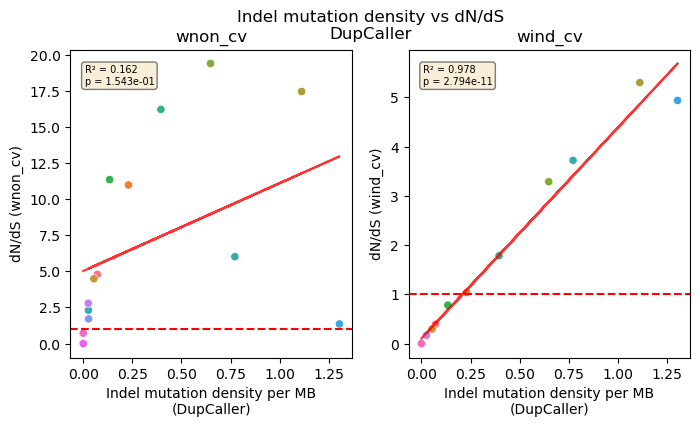

In [36]:
fig, axes = plt.subplots(figsize=(8, 4), nrows=1, ncols=2)
for impact in ['wnon_cv', 'wind_cv']:
    axis = axes[0] if impact == 'wnon_cv' else axes[1]
    # print(dupcaller_dnds_mutdensity[dupcaller_dnds_mutdensity["impact"] == impact])
    selected_df = dupcaller_dnds_mutdensity[dupcaller_dnds_mutdensity["impact"] == impact]
    sns.scatterplot(data=selected_df,
                x="MUTDENSITY_MB",
                y="dnds",
                hue = 'gene_name',
                ax=axis,
                legend=False,
            # kind="box",
            # height=4, aspect=1.5
            )
    
    # Add regression line
    slope, intercept, r_value, p_value, std_err = linregress(selected_df['MUTDENSITY_MB'], selected_df['dnds'])
    line = slope * selected_df['MUTDENSITY_MB'] + intercept
    axis.plot(selected_df['MUTDENSITY_MB'], line, 'r', alpha=0.8)
    axis.text(0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.3e}', 
                transform=axis.transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize = 7
                )

    axis.set_title(f"{impact}")
    axis.set_xlabel(f"Indel mutation density per MB\n(DupCaller)")
    axis.set_ylabel(f"dN/dS ({impact})")
    axis.axhline(y=1, color='r', linestyle='--')

    # max_dnds = max(dupcaller_dnds_mutdensity["dnds_dupcaller"].max(), dupcaller_dnds_mutdensity["dnds_deepumicaller"].max()) * 1.1

    # # add x = y line
    # axis.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
    # axis.set_xscale('log')
    # axis.set_yscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().remove()
fig.suptitle("Indel mutation density vs dN/dS\nDupCaller")
plt.savefig("../plots/dupcaller.indel_mutation_density_vs_dnds.pdf", bbox_inches='tight', dpi=300)
plt.show()